In [2]:
import pandas as pd
import numpy as np

In [4]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier 

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer

from sklearn.compose import ColumnTransformer

In [3]:
df= pd.read_csv('titanic.csv', usecols=['Age','Fare','Survived'])

In [5]:
df.dropna(inplace=True)

In [6]:
df.shape

(714, 3)

In [7]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [8]:
X=df.iloc[:,1:]
y=df.iloc[:,0]


In [9]:
X_train,X_test, y_train,y_test= train_test_split(X,y,test_size=0.3, random_state=0)
X_train.head(5)


,Age,Fare
200,28.0,9.5000
439,31.0,10.5000
100,28.0,7.8958
117,29.0,21.0000
625,61.0,32.3208


In [10]:
clf= DecisionTreeClassifier()

In [13]:
clf.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
y_pred=clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.5767441860465117

In [18]:
np.mean(cross_val_score(
    DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'
))

np.float64(0.6260954616588419)

In [25]:
kbin_age= KBinsDiscretizer( n_bins=15, encode='ordinal', strategy='quantile')

kbin_fare= KBinsDiscretizer( n_bins= 15, encode='ordinal', strategy='quantile')

In [26]:
trf= ColumnTransformer([
    ( 'first', kbin_age, [0]),
    ('second', kbin_fare,[1])
])

In [27]:
X_train_trf= trf.fit_transform(X_train)
X_test_trf= trf.transform(X_test)


c:\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [28]:
trf.named_transformers_['first'].bin_edges_


array([array([ 0.67,  7.  , 16.  , 18.  , 21.  , 22.  , 25.  , 27.  , 29.  ,
              31.  , 34.  , 37.  , 41.  , 47.  , 52.8 , 74.  ])             ],
      dtype=object)

In [29]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.67,  7.  , 16.  , 18.  , 21.  , 22.  , 25.  , 27.  , 29.  ,
              31.  , 34.  , 37.  , 41.  , 47.  , 52.8 , 74.  ])             ],
      dtype=object)

In [32]:
output= pd.DataFrame({
    'age': X_train['Age'],
    'age_trf': X_train_trf[:,0],
    'fare': X_train['Fare'],
    'fare_trf': X_train_trf[:,1]
}
)

In [31]:
output['age-labels'] = pd.cut( x=X_train['Age'], bins= trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels']= pd.cut( x=X_train['Fare'], bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [33]:
output.sample(5)

,age,age_trf,fare,fare_trf
748,19.0,3.0,53.1000,12.0
761,41.0,12.0,7.1250,0.0
342,28.0,7.0,13.0000,6.0
654,18.0,3.0,6.7500,0.0
519,32.0,9.0,7.8958,2.0


In [34]:
clf=DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)
y_pred2= clf.predict(X_test_trf)

In [35]:
accuracy_score(y_test, y_pred2)

0.6651162790697674

In [36]:
X_trf= trf.fit_transform(X)

np.mean(cross_val_score( DecisionTreeClassifier(), X, y, cv=10, scoring='accuracy'))


c:\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6288732394366197)

In [40]:
def discetize(bins, strategy):

    kbin_age= KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy= strategy)

    kbin_fare= KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy= strategy)

    trf= ColumnTransformer([
        ('first', kbin_age,[0]),
        ('second', kbin_fare, [1])
    ])

    X_trf= trf.fit_transform(X)
    print(np.mean(cross_val_score( DecisionTreeClassifier(),X, y , cv= 10, scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title('Before')

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist( X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1], color= 'red')
    plt.title('fare')
    plt.show()

0.6331377151799688


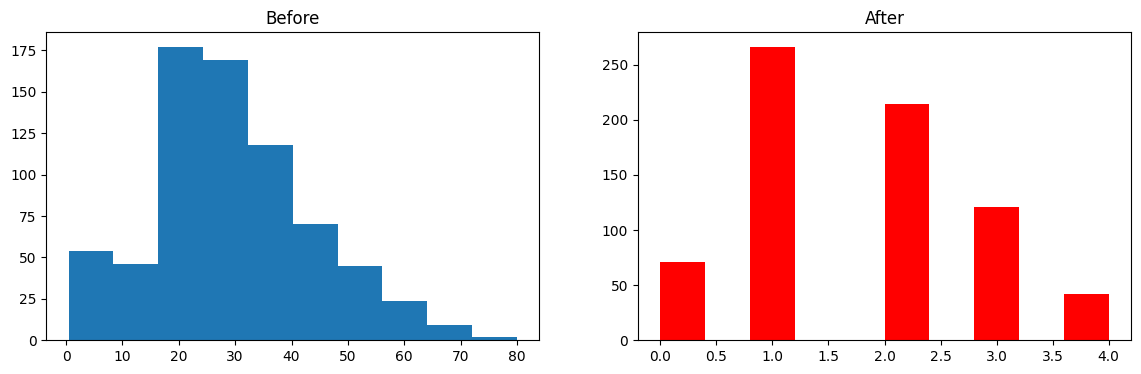

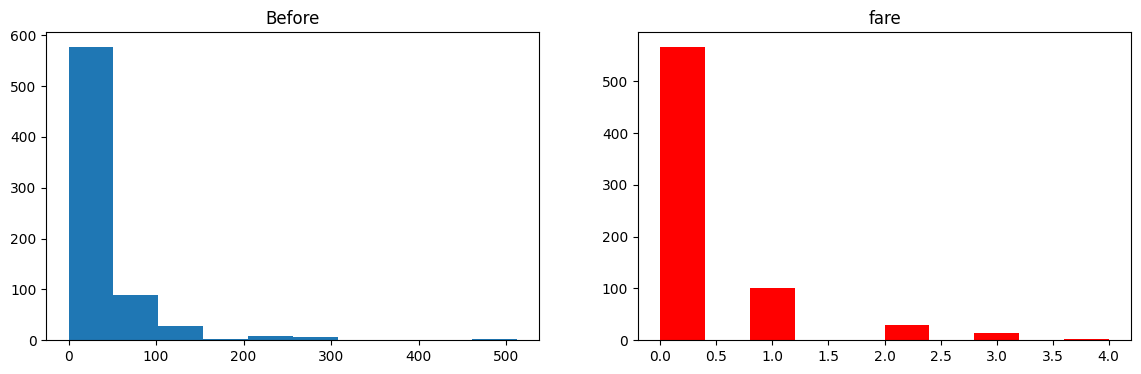

In [41]:
discetize(5,'kmeans')